<a href="https://colab.research.google.com/github/RosarioH10062002/M2_master_thesis/blob/main/EEG_Behavioral_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import drive
drive.mount('/content/drive')
try:
  from emgio.importers.xdf import summarize_xdf as emgio_summarize_xdf
except:
  !pip install emgio
  from emgio.importers.xdf import summarize_xdf as emgio_summarize_xdf
try:
  import pyxdf
except:
  !pip install pyxdf
  import pyxdf
try:
  from brainflow.data_filter import DataFilter, FilterTypes
except:
  !pip install brainflow
  from brainflow.data_filter import DataFilter, FilterTypes

from matplotlib import colors
import plotly.express as px
import matplotlib.image as mpimg
import inspect
from scipy.stats import zscore
# To open a google sheets
from google.colab import auth
auth.authenticate_user()

import gspread
from google.auth import default
creds, _ = default()
gc = gspread.authorize(creds)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
root_path_weeks = Path("/content/drive/My Drive/M2_Project_Master/Data/Participants data/Second Phase/W1")

In [ ]:
list_participants = os.listdir(root_path_weeks)
print(list_participants)

['ID2', 'ID6', 'ID10', 'ID13', 'ID8', 'ID5']


In [ ]:
def get_pathlist_behavior_eeg():
  participants = os.listdir(root_path_weeks)
  participants_data = {}
  for participant in participants:
    content = os.listdir(root_path_weeks/participant)
    list_xdf = [root_path_weeks/participant/a for a in content if a.endswith(".xdf")]
    list_behavior = [root_path_weeks/participant/a for a in content if a.endswith(".csv")]
    participants_data[participant] = {
        "xdf": list_xdf,
        "behavior": list_behavior
    }
  return participants_data

In [ ]:
participants_data = get_pathlist_behavior_eeg()
participants_data["ID2"]["behavior"]

[PosixPath('/content/drive/My Drive/M2_Project_Master/Data/Participants data/Second Phase/W1/ID2/Behavior_1.csv'),
 PosixPath('/content/drive/My Drive/M2_Project_Master/Data/Participants data/Second Phase/W1/ID2/Behavior_2.csv')]

#**XDF FUNCTIONS**

In [ ]:
def get_xdf_s(xdf):
  summary = emgio_summarize_xdf(xdf)
  print(summary)

In [ ]:
def read_xdf(xdf):
  streams, header = pyxdf.load_xdf(xdf)
  return streams, header

In [ ]:
#INFO STREAMS
list_xdf, _ = get_list_behavior_eeg()
get_xdf_s(xdf = list_xdf[0])

XDF File: /content/drive/My Drive/M2_Project_Master/Data/Participants data/Second Phase/W1/ID5/EEG_Behavior_1.xdf
Number of streams: 2

Stream 1: OpenBCI_EEG
  Type: EEG
  Channels: 8
  Nominal srate: 250.0 Hz
  Effective srate: 862.30 Hz
  Samples: 823498
  Duration: 955.00 s
  Format: float32
  Channel labels: Ch1, Ch2, Ch3, Ch4, Ch5, ... (+3 more)

Stream 2: Psychopy_markers
  Type: Markers
  Channels: 1
  Nominal srate: 0.0 Hz
  Effective srate: 1.11 Hz
  Samples: 1044
  Duration: 940.35 s
  Format: int32
  Channel labels: Ch1



#**PSYCHOPY FUNCTIONS**

In [ ]:
def get_pandas_beh(id):
  list_beh = []
  participants_data = get_pathlist_behavior_eeg()
  participant_behavior = participants_data[f"ID{id}"]["behavior"]
  for participant in participant_behavior:
    pd_participant = pd.read_csv(participant, sep = ",")
    if pd_participant.shape[1] == 1:
      pd_participant = pd.read_csv(participant, sep = ";")
    list_beh.append(pd_participant)
  return list_beh

In [ ]:
def clean_all_data(df):
    df = df.drop(["fc(hz)", "fb(hz)", "stimulus_code"], axis=1)
    df["rt(s)"] = df["rt(s)"].astype(float)
    df["trial"] = range(df.shape[0])
    return df

def plot_reaccion_time_dots(df, id, gender, asrs):
  x_values = df["trial"] # time
  # I want that each point is colored if its right or wrong
  y_values = df["rt(s)"]

  #x_values_wrong = df[df["correct"] == "Incorrect"]["trial"]
  #y_values_wrong = df[df["correct"] == "Incorrect"]["rt(s)"]

  x_values_right = df[df["correct"] == "Correct"]["trial"]
  y_values_right = df[df["correct"] == "Correct"]["rt(s)"]

  x_values_omission = df[df["is_omission"] == True]["trial"]
  y_values_omission = df[df["is_omission"] == True]["rt(s)"]

  x_values_comission = df[df["is_comission"] == True]["trial"]
  y_values_comission = df[df["is_comission"] == True]["rt(s)"]

  plt.figure(figsize=(20, 6))
  plt.plot(x_values, y_values, color = "gray")
  plt.plot(x_values_right, y_values_right, "go", label = "Right Answers")
  #plt.plot(x_values_wrong, y_values_wrong, "ro")
  plt.plot(x_values_omission, y_values_omission, "bo", label = "Omission Errors")
  plt.plot(x_values_comission, y_values_comission, "ro", label = "Comission Errors")

  plt.xlabel("Trial Number")
  plt.ylabel("Reaction Time (s)")
  plt.title(f"Reaction Time per Trial - ID{id} - Gender : {gender} - ASRS: {asrs}")
  plt.grid(True)

  plt.axvline(x=44, color='hotpink', linestyle='--', label='Trial Phase')
  plt.axvline(x = 134, color='darkcyan', linestyle='--', label='Block 1 - Main Phase')
  plt.axvline(x = 224, color='darkcyan', linestyle='--', label='Block 2 - Main Phase')
  plt.axvline(x = 314, color='darkcyan', linestyle='--', label='Block 3 - Main Phase')
  plt.axvline(x = 404, color='darkcyan', linestyle='--', label='Block 4 - Main Phase')
  plt.axvline(x = 494, color='darkcyan', linestyle='--', label='Block 5 - Main Phase')
  plt.axvline(x = 584, color='darkcyan', linestyle='--', label='Block 6 - Main Phase')
  plt.legend()

  plt.savefig(f"plot_reacction_time_ID{id}.png")
  plt.show()

def compute_accuracy(df, trial):
  df_go_trials = df[df["stimulus_type"] == "Go"]
  n_total_go = df_go_trials.shape[0]
  #print(f"n_total_go: {n_total_go}")
  n_correct_go = df_go_trials[df_go_trials["correct"] == "Correct"].shape[0]
  accuracy_go = n_correct_go / n_total_go if n_total_go > 0 else 0

  df_No_Go_trials = df[df["stimulus_type"] == "No_Go"]
  n_total_No_Go = df_No_Go_trials.shape[0]
  #print(f"n_total_No_Go: {n_total_No_Go}")
  n_correct_No_Go = df_No_Go_trials[df_No_Go_trials["correct"] == "Correct"].shape[0]
  accuracy_No_Go = n_correct_No_Go / n_total_No_Go if n_total_No_Go > 0 else 0

  #print(f"Accuracy Go: {accuracy_go} \nAccuracy No Go (pain_au_chocolat): {accuracy_No_Go}")
  return accuracy_go, accuracy_No_Go

def compute_both_accuracy(df):
  [accuracy_go, accuracy_No_Go] = compute_accuracy(df = df[0:45], trial = True) # trial
  all_accuracy_data = []
  all_accuracy_data.append({"Phase": "Trial", "Accuracy Go": accuracy_go, "Accuracy No Go": accuracy_No_Go})

  for block in range(6):
    start = 45 + block*90
    end = start + 90
    #print(f"start: {start}, end {end}")
    [accuracy_go, accuracy_No_Go] = compute_accuracy(df = df[start:end], trial = False)
    all_accuracy_data.append({"Phase": f"Block {block+1}", "Accuracy Go": accuracy_go, "Accuracy No Go": accuracy_No_Go})
  return all_accuracy_data

def plot_accuracy(data, id, merge, gender, asrs):
  labels = [data[x].get("Phase") for x in range(7)]
  list_accuracy_go = [data[x].get("Accuracy Go") for x in range(7)]
  list_accuracy_No_Go = [data[x].get("Accuracy No Go") for x in range(7)]
  #print(list_accuracy_go)
  if merge != True:
    plt.figure(figsize=(20, 6))
    plt.plot(labels, list_accuracy_go, color = "darkviolet")
    plt.xlabel("Phase")
    plt.ylabel("Accuracy (%)")
    plt.title(f"Accuracy Go per Trial - ID{id}")
    plt.grid(True)
    plt.show()


    plt.figure(figsize=(20, 6))
    plt.plot(labels, list_accuracy_No_Go, color = "dodgerblue")
    plt.xlabel("Phase")
    plt.ylabel("Accuracy (%)")
    plt.title(f"Accuracy No-Go (Pain Au Chocolat) per trial - ID{id} - Gender : {gender}")
    plt.grid(True)
    plt.show()
  else:
    plt.figure(figsize=(20, 6))
    plt.plot(labels, list_accuracy_go, label = "Accuracy Go per Trial", color = "darkviolet")
    plt.plot(labels, list_accuracy_No_Go, label = "Accuracy No Go (pain au chocolat) per Trial", color = "dodgerblue")
    plt.xlabel("Phase")
    plt.ylabel("Accuracy (%)")
    plt.title(f"Accuracy per trial - ID{id} - Gender : {gender}- ASRS: {asrs}")
    plt.grid(True)
    plt.legend()
    plt.show()
def split_data(df):
  trial = df[df["block_index"].isna()]
  block_1 = df[df["block_index"] == 1]
  block_2 = df[df["block_index"] == 2]
  block_3 = df[df["block_index"] == 3]
  block_4 = df[df["block_index"] == 4]
  block_5 = df[df["block_index"] == 5]
  block_6 = df[df["block_index"] == 6]
  return trial, block_1,block_2,block_3,block_4,block_5,block_6

def plot_variability_rt(df, id, gender, asrs): # variability = std(rt_1block)
  [trial, block_1,block_2,block_3,block_4,block_5,block_6] = split_data(df)

  std_trial_No_Go = np.nanstd(trial[trial["stimulus_type"] == "No_Go"]["rt(s)"])
  std_block_1_No_Go = np.nanstd(block_1[block_1["stimulus_type"] == "No_Go"]["rt(s)"])
  std_block_2_No_Go = np.nanstd(block_2[block_2["stimulus_type"] == "No_Go"]["rt(s)"])
  std_block_3_No_Go = np.nanstd(block_3[block_3["stimulus_type"] == "No_Go"]["rt(s)"])
  std_block_4_No_Go = np.nanstd(block_4[block_4["stimulus_type"] == "No_Go"]["rt(s)"])
  std_block_5_No_Go = np.nanstd(block_5[block_5["stimulus_type"] == "No_Go"]["rt(s)"])
  std_block_6_No_Go = np.nanstd(block_6[block_6["stimulus_type"] == "No_Go"]["rt(s)"])

  std_trial_go = np.nanstd(trial[trial["stimulus_type"] == "Go"]["rt(s)"])
  std_block_1_go = np.nanstd(block_1[block_1["stimulus_type"] == "Go"]["rt(s)"])
  std_block_2_go = np.nanstd(block_2[block_2["stimulus_type"] == "Go"]["rt(s)"])
  std_block_3_go = np.nanstd(block_3[block_3["stimulus_type"] == "Go"]["rt(s)"])
  std_block_4_go = np.nanstd(block_4[block_4["stimulus_type"] == "Go"]["rt(s)"])
  std_block_5_go = np.nanstd(block_5[block_5["stimulus_type"] == "Go"]["rt(s)"])
  std_block_6_go = np.nanstd(block_6[block_6["stimulus_type"] == "Go"]["rt(s)"])

  std_overall_trial = np.nanstd(trial["rt(s)"])
  std_overall_block_1 = np.nanstd(block_1["rt(s)"])
  std_overall_block_2 = np.nanstd(block_2["rt(s)"])
  std_overall_block_3 = np.nanstd(block_3["rt(s)"])
  std_overall_block_4 = np.nanstd(block_4["rt(s)"])
  std_overall_block_5 = np.nanstd(block_5["rt(s)"])
  std_overall_block_6 = np.nanstd(block_6["rt(s)"])

  y_vals_No_Go = [std_trial_No_Go,std_block_1_No_Go,std_block_2_No_Go,std_block_3_No_Go,std_block_4_No_Go,std_block_5_No_Go,std_block_6_No_Go]
  y_vals_go = [std_trial_go,std_block_1_go,std_block_2_go,std_block_3_go,std_block_4_go,std_block_5_go,std_block_6_go]
  y_vals_overall = [std_overall_trial,std_overall_block_1,std_overall_block_2,std_overall_block_3,std_overall_block_4,std_overall_block_5,std_overall_block_6]
  #print(y_vals)
  x_vals = ["Trial"] + [f"Block {i+1}" for i in range(6)]
  plt.figure(figsize=(20, 6))
  plt.plot(x_vals, y_vals_No_Go, color = "dodgerblue", label = "Variability No Go (Pain au chocolat)")
  plt.plot(x_vals, y_vals_go,   color = "darkviolet", label = "Variability Go")
  plt.plot(x_vals, y_vals_overall,   color = "aquamarine", label = "Overall Variability (Go + No Go)")

  plt.xlabel("Phases")
  plt.ylabel("std(Reaction Time (s))")
  plt.title(f"Reaction Time Variability per Trial- ID{id} - Gender : {gender} - ASRS: {asrs}")
  plt.grid(True)
  plt.legend()
  plt.savefig(f"plot_RT_var_ID{id}.png")
  plt.show()
  return 0

def plot_total_histogramme(df):
  rt = df["rt(s)"]
  plt.hist(rt, 100, edgecolor = "white", color='skyblue') # Added color
  plt.xlabel("RT(s)")
  plt.ylabel("Frequency")
  plt.title("Overall Trial + Main Task")
  plt.show()

def plot_histogramme_per_block(df):
  n_bins = 100
  [trial, block_1, block_2, block_3, block_4, block_5, block_6] = split_data(df)

  fig, axs = plt.subplots(4, 2, tight_layout=True, figsize = (20,10))

  colors = ['lightgreen', 'skyblue']

  axs[0,0].hist(trial["rt(s)"], n_bins, edgecolor = "white", color=colors[0])
  axs[0,0].set_title("Trial")

  axs[0,1].hist(block_1["rt(s)"], n_bins, edgecolor = "white", color=colors[1])
  axs[0,1].set_title("Block 1")

  axs[1,0].hist(block_2["rt(s)"], n_bins, edgecolor = "white", color=colors[1])
  axs[1,0].set_title("Block 2")

  axs[1,1].hist(block_3["rt(s)"], n_bins, edgecolor = "white", color=colors[1])
  axs[1,1].set_title("Block 3")

  axs[2,0].hist(block_4["rt(s)"], n_bins, edgecolor = "white", color=colors[1])
  axs[2,0].set_title("Block 4")

  axs[2,1].hist(block_5["rt(s)"], n_bins, edgecolor = "white", color=colors[1])
  axs[2,1].set_title("Block 5")

  axs[3,0].hist(block_6["rt(s)"], n_bins, edgecolor = "white", color=colors[1])
  axs[3,0].set_title("Block 6")

  axs[3,1].set_visible(False)

  plt.show()

def plot_3_histogramme_per_block(df, id, gender, asrs):
  n_bins = 100
  [trial, block_1, block_2, block_3, block_4, block_5, block_6] = split_data(df)

  blocks_list = [trial, block_1, block_2, block_3, block_4, block_5, block_6] # List of block DataFrames

  for i, block_df in enumerate(blocks_list):
    fig, axs = plt.subplots(1, 3, tight_layout=True, figsize = (20,5))
    block_num = i

    axs[0].hist(block_df["rt(s)"], n_bins, edgecolor = "white", color='aquamarine')
    axs[0].set_title(f"Block {block_num} - Overall RT")
    axs[0].set_xlabel("RT(s)")
    axs[0].set_ylabel("Frequency")
    axs[0].grid(True)

    No_Go_df = block_df[block_df["stimulus_type"] == "No_Go"]
    axs[1].hist(No_Go_df["rt(s)"], n_bins, edgecolor = "white", color='darkviolet')
    axs[1].set_title(f"Block {block_num} - No Go (pain au chocolat) RT")
    axs[1].set_xlabel("RT(s)")
    axs[1].set_ylabel("Frequency")
    axs[1].grid(True)

    go_df = block_df[block_df["stimulus_type"] == "Go"]
    axs[2].hist(go_df["rt(s)"], n_bins, edgecolor = "white", color='dodgerblue')
    axs[2].set_title(f"Block {block_num} - Go RT")
    axs[2].set_xlabel("RT(s)")
    axs[2].set_ylabel("Frequency")
    axs[2].grid(True)
    if i == 0:
      plt.suptitle(f"Histograms for Trial - ID{id} - Gender : {gender} - ASRS: {asrs}", fontsize=16)
    else:
      plt.suptitle(f"Histograms for Block {block_num} - ID{id} - Gender : {gender} - ASRS: {asrs}", fontsize=16)

    plt.show()


In [ ]:
def add_omission_comission(df):

    df["is_omission"] = (
        (df["stimulus_type"] == "Go") &
        (df["resp_key"].isna())
    )

    df["is_comission"] = (
        (df["stimulus_type"] == "No_Go") &
        (df["resp_key"].notna())
    )

    return df

In [ ]:
def get_info_participants():
  worksheet = gc.open("ID participants").sheet1
  rows = worksheet.get_all_values()
  columns = rows[0]
  info_participants = pd.DataFrame(rows[1:])
  info_participants.columns = columns
  info_participants.columns = info_participants.columns.str.strip()
  #print(columns)
  return info_participants
#info_participants = get_info_participants()
#info_participants.to_csv("info_participants.csv")

def get_gender(id):
  info_participants = get_info_participants()
  return info_participants["GENDER"][id-1]

def get_asrs_score(id):
  info_participants = get_info_participants()
  return info_participants["ASRS"][id-1]

In [ ]:
from scipy.stats import mannwhitneyu


def pipeline_statistical_test(id):

    df_clean_list = []
    df_raw_list = get_pandas_beh(id)

    for df_raw in df_raw_list:
        df_clean = clean_all_data(df_raw)
        df = add_omission_comission(df_clean)
        df_clean_list.append(df)

    df_s1 = df_clean_list[0]
    df_s2 = df_clean_list[1]

    results = {}

    #RT
    rt_s1 = df_s1[df_s1["stimulus_type"]=="Go"]["rt(s)"].dropna()
    rt_s2 = df_s2[df_s2["stimulus_type"]=="Go"]["rt(s)"].dropna()

    stat, p_rt = mannwhitneyu(rt_s1, rt_s2, alternative='two-sided')
    results["RT_Go"] = p_rt

    # improvement (lower RT is better)
    results["RT_Go_improved"] = np.median(rt_s2) < np.median(rt_s1)

    #OMISSION
    om_s1 = df_s1["is_omission"].astype(int)
    om_s2 = df_s2["is_omission"].astype(int)

    stat, p_om = mannwhitneyu(om_s1, om_s2, alternative='two-sided')
    results["Omission"] = p_om

    # improvement (lower omission is better)
    results["Omission_improved"] = om_s2.mean() < om_s1.mean()

    #COMISSION
    com_s1 = df_s1["is_comission"].astype(int)
    com_s2 = df_s2["is_comission"].astype(int)

    stat, p_com = mannwhitneyu(com_s1, com_s2, alternative='two-sided')
    results["Commission"] = p_com

    # improvement (lower commission is better)
    results["Commission_improved"] = com_s2.mean() < com_s1.mean()

    #ACCURACY
    acc_s1 = (df_s1["correct"] == "Correct").astype(int)
    acc_s2 = (df_s2["correct"] == "Correct").astype(int)

    stat, p_acc = mannwhitneyu(acc_s1, acc_s2, alternative='two-sided')
    results["Accuracy"] = p_acc

    # improvement (higher accuracy is better)
    results["Accuracy_improved"] = acc_s2.mean() > acc_s1.mean()

    return results

In [ ]:
def pipeline(id):
  df_clean_list = []
  #df_raw = get_pandas_dataset(id)
  df_raw_list = get_pandas_beh(id)
  for df_raw in df_raw_list:
    df_clean = clean_all_data(df_raw)
    df = add_omission_comission(df_clean)
    #df= df_clean
    gender = get_gender(id)
    asrs = get_asrs_score(id)
    df_clean_list.append(df)
    #plot_reaccion_time_dots(df, id, gender, asrs)
  #return df_clean_list
    all_accuracy_data = compute_both_accuracy(df)
    plot_accuracy(data = all_accuracy_data, id = id, merge = True, gender = gender, asrs = asrs)
    #plot_variability_rt(df, id, gender, asrs)
  for df_raw in df_raw_list:
    df_clean = clean_all_data(df_raw)
    df = add_omission_comission(df_clean)
    #df= df_clean
    gender = get_gender(id)
    asrs = get_asrs_score(id)
    #df_clean_list.append(df)
    #plot_reaccion_time_dots(df, id, gender, asrs)
  #return df_clean_list
    plot_variability_rt(df, id, gender, asrs)
  return df_clean_list
    #plot_3_histogramme_per_block(df, id, gender, asrs)

#**ID6**

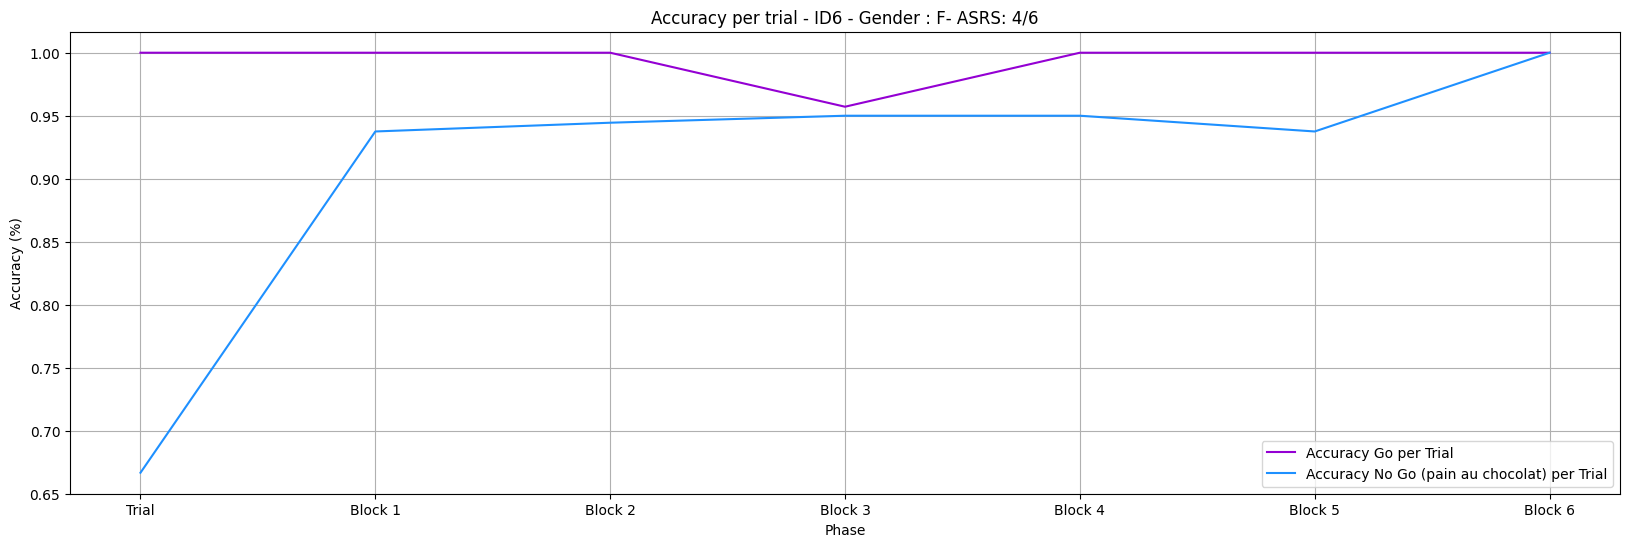

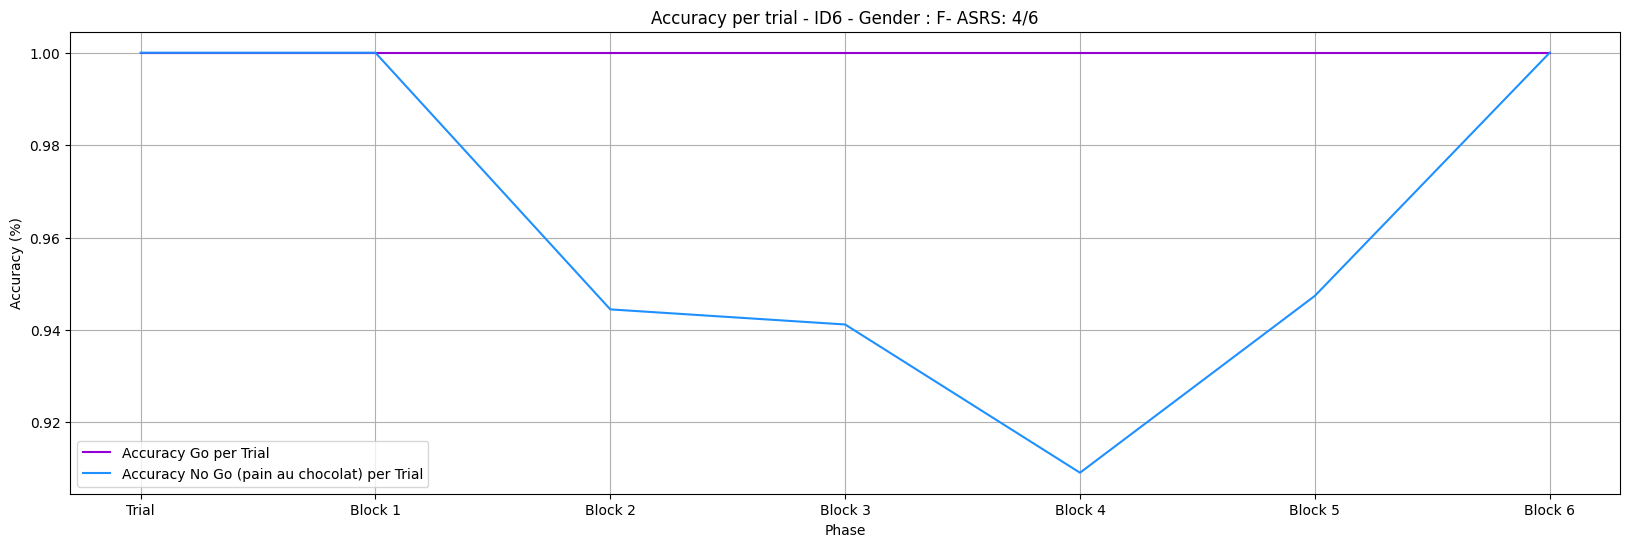

/usr/local/lib/python3.12/dist-packages/numpy/lib/_nanfunctions_impl.py:2035: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


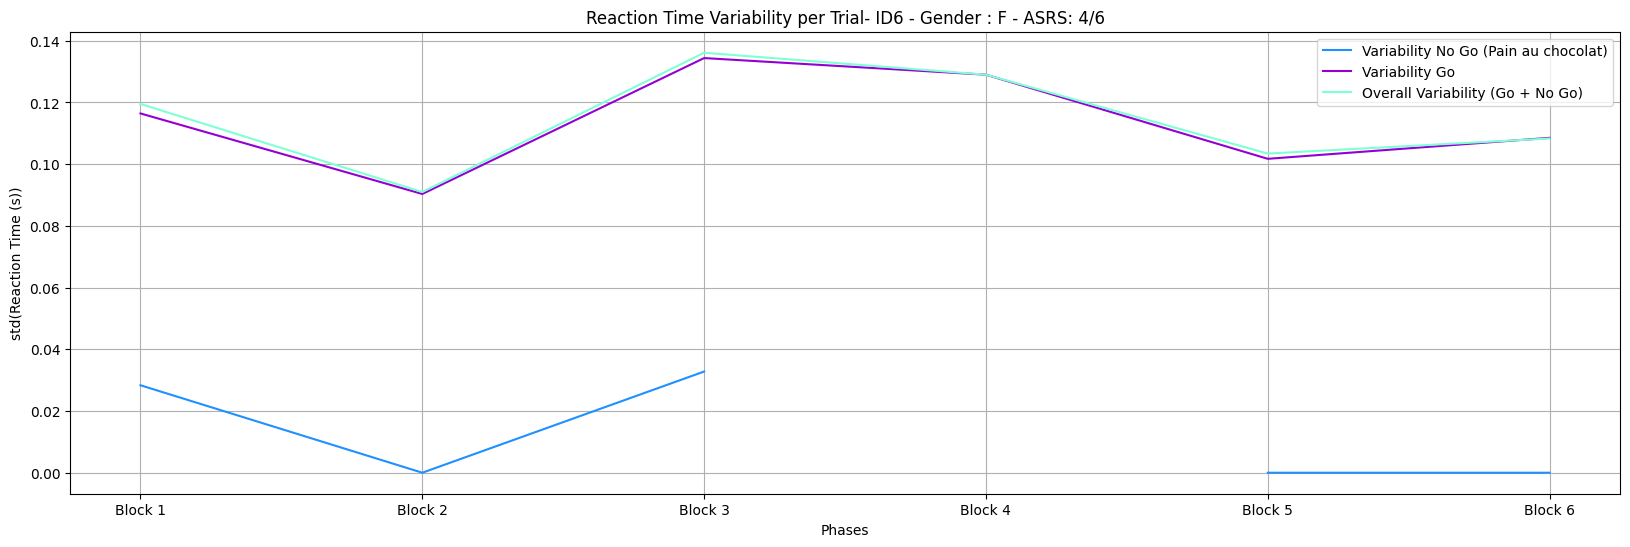

/usr/local/lib/python3.12/dist-packages/numpy/lib/_nanfunctions_impl.py:2035: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


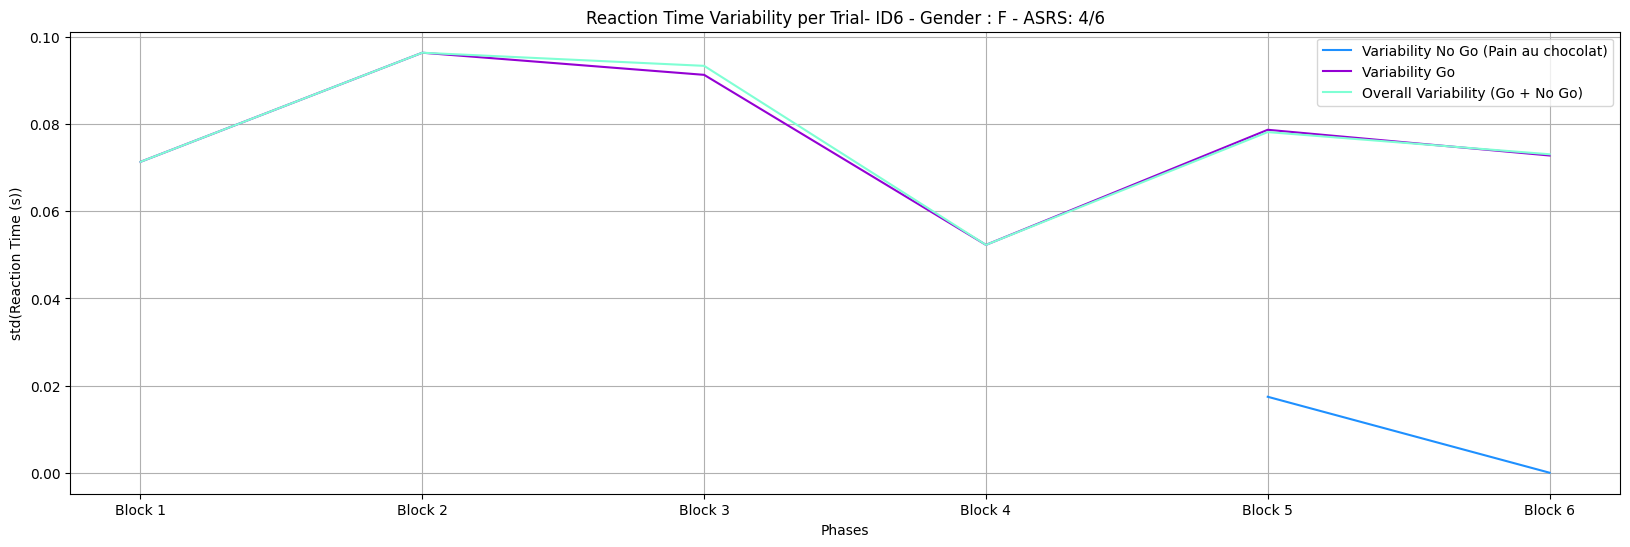

In [ ]:
df_clean_list = pipeline(id = 6)

In [ ]:
pipeline_statistical_test(id = 6)

{'RT_Go': np.float64(8.146890850294491e-11),
 'Omission': np.float64(0.08316890226023901),
 'Commission': np.float64(0.4030426559697241),
 'Accuracy': np.float64(0.13102554085318377)}

#**ID2**

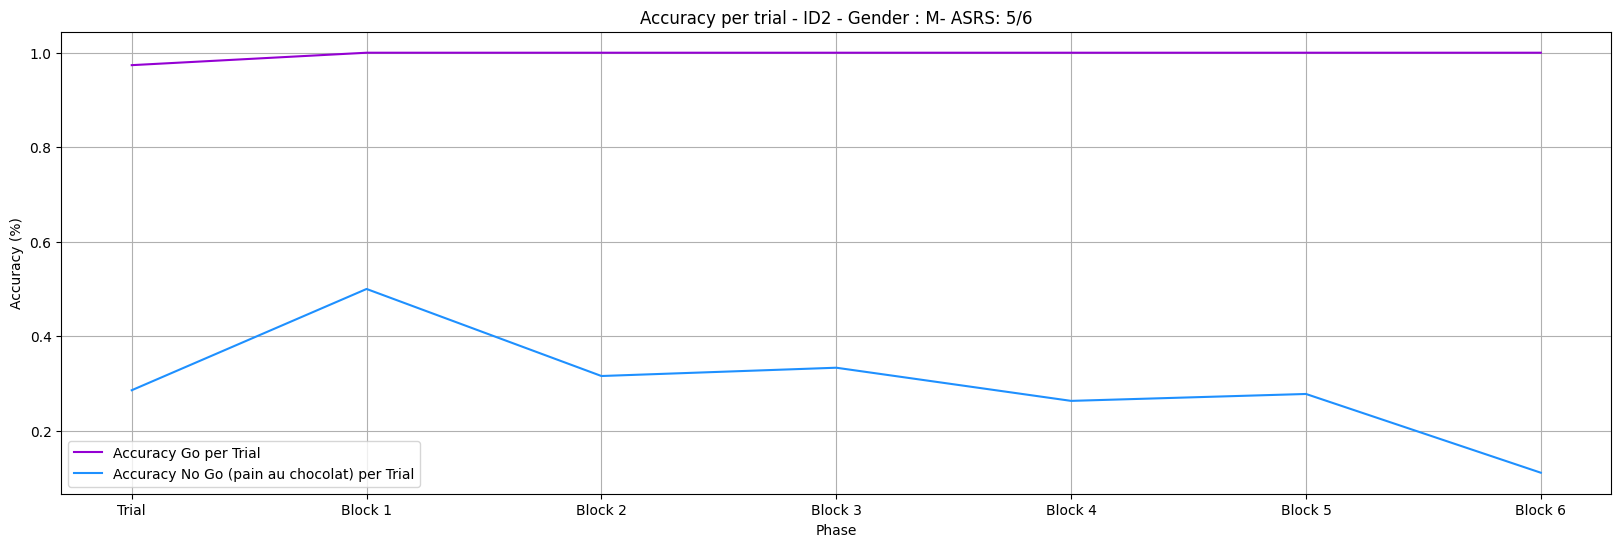

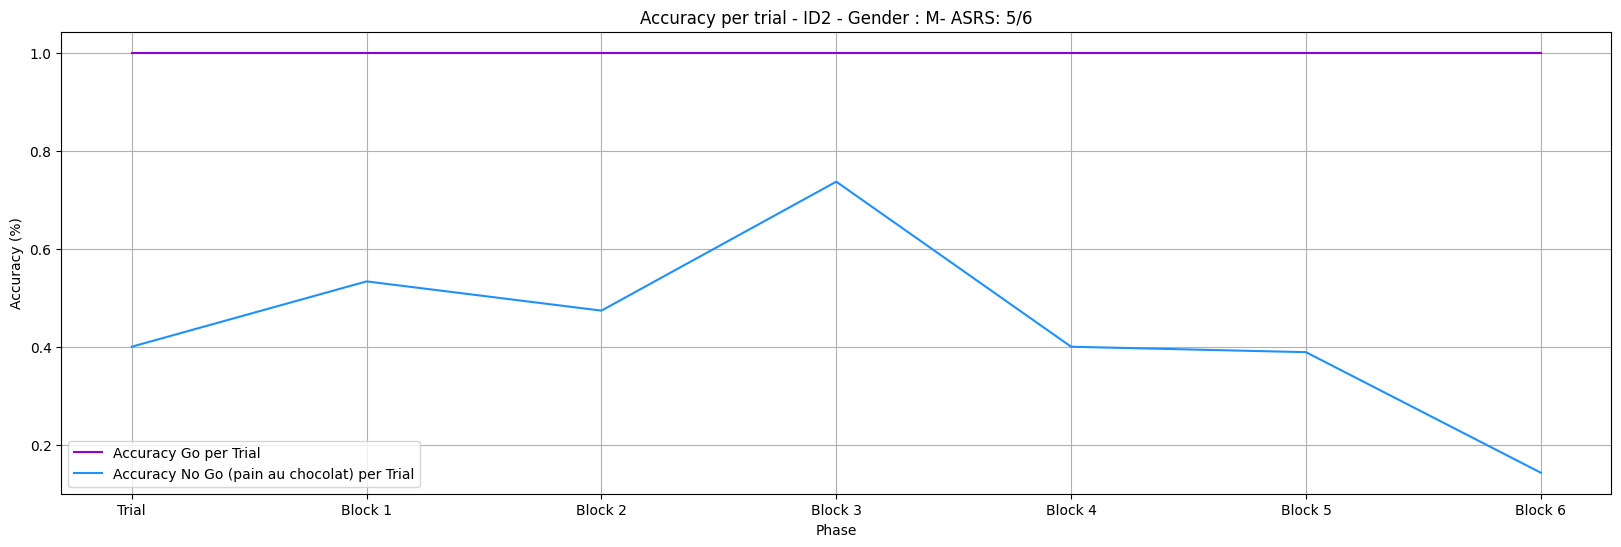

/usr/local/lib/python3.12/dist-packages/numpy/lib/_nanfunctions_impl.py:2035: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


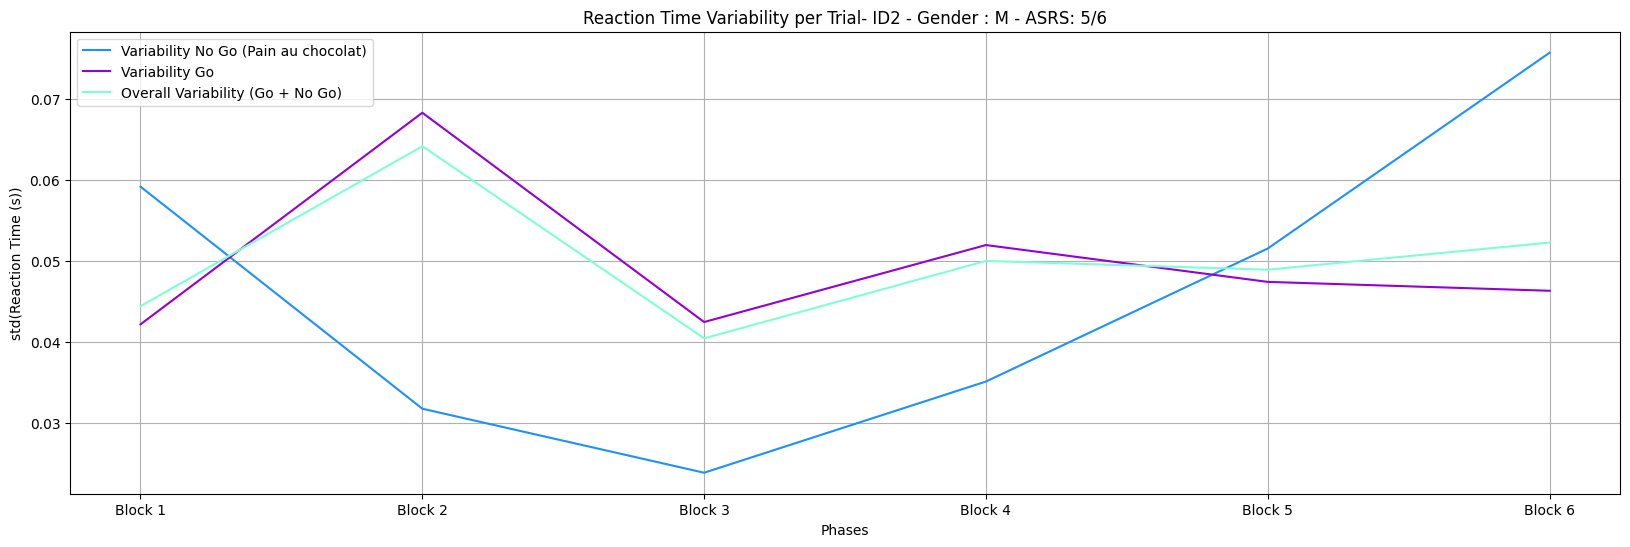

/usr/local/lib/python3.12/dist-packages/numpy/lib/_nanfunctions_impl.py:2035: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


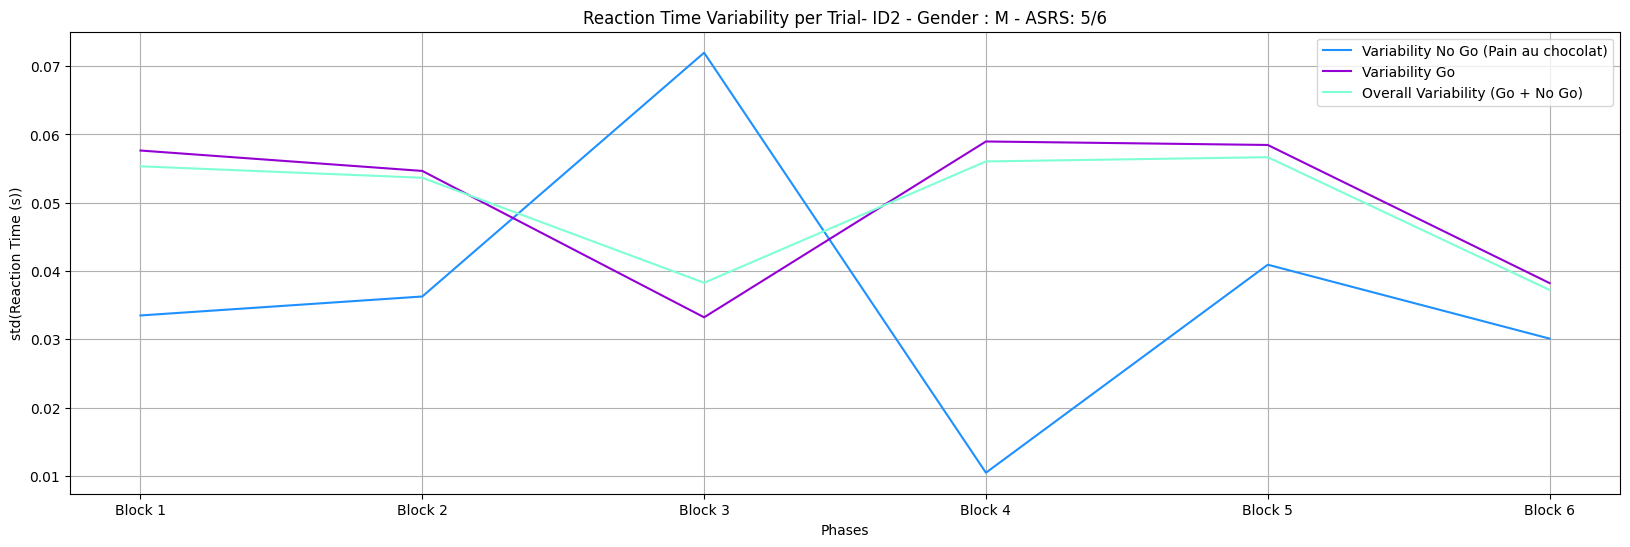

In [ ]:
pipeline(id = 2)

In [ ]:
pipeline_statistical_test(id = 2)

{'RT_Go': np.float64(0.9199409479140096),
 'Omission': np.float64(0.3182075255346112),
 'Commission': np.float64(0.11328636378309369),
 'Accuracy': np.float64(0.09466775683943451)}

#**ID5**

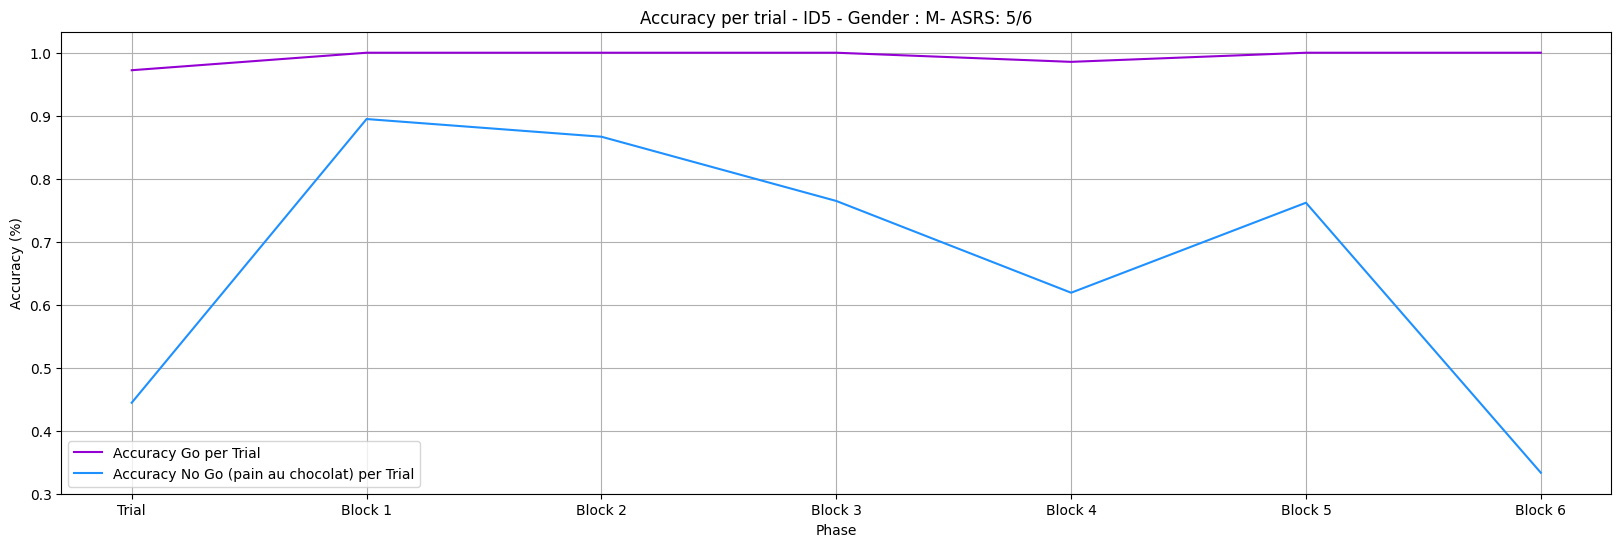

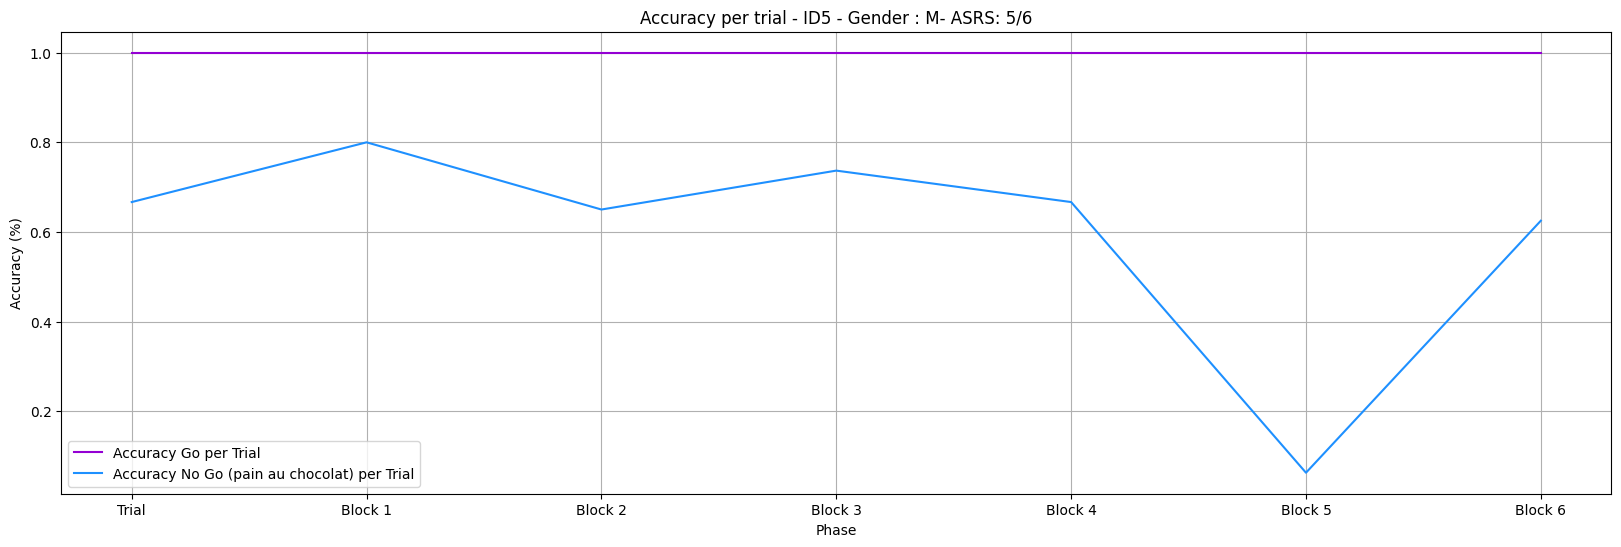

/usr/local/lib/python3.12/dist-packages/numpy/lib/_nanfunctions_impl.py:2035: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


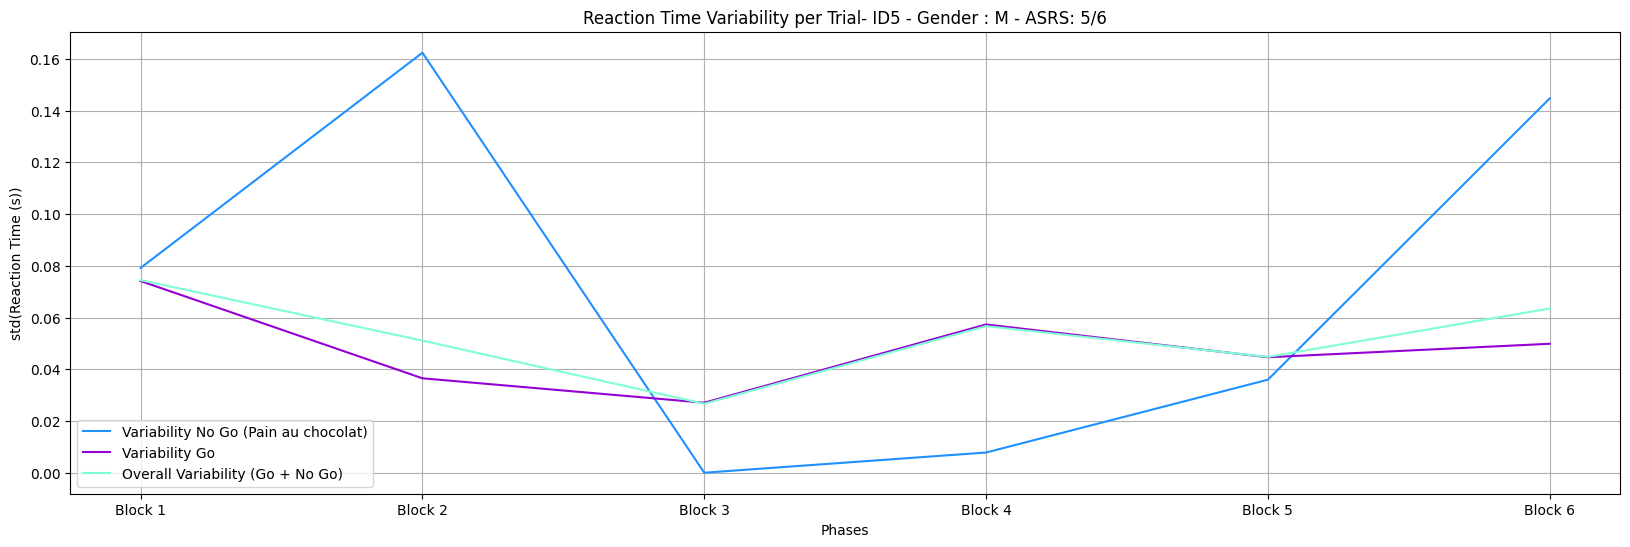

/usr/local/lib/python3.12/dist-packages/numpy/lib/_nanfunctions_impl.py:2035: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


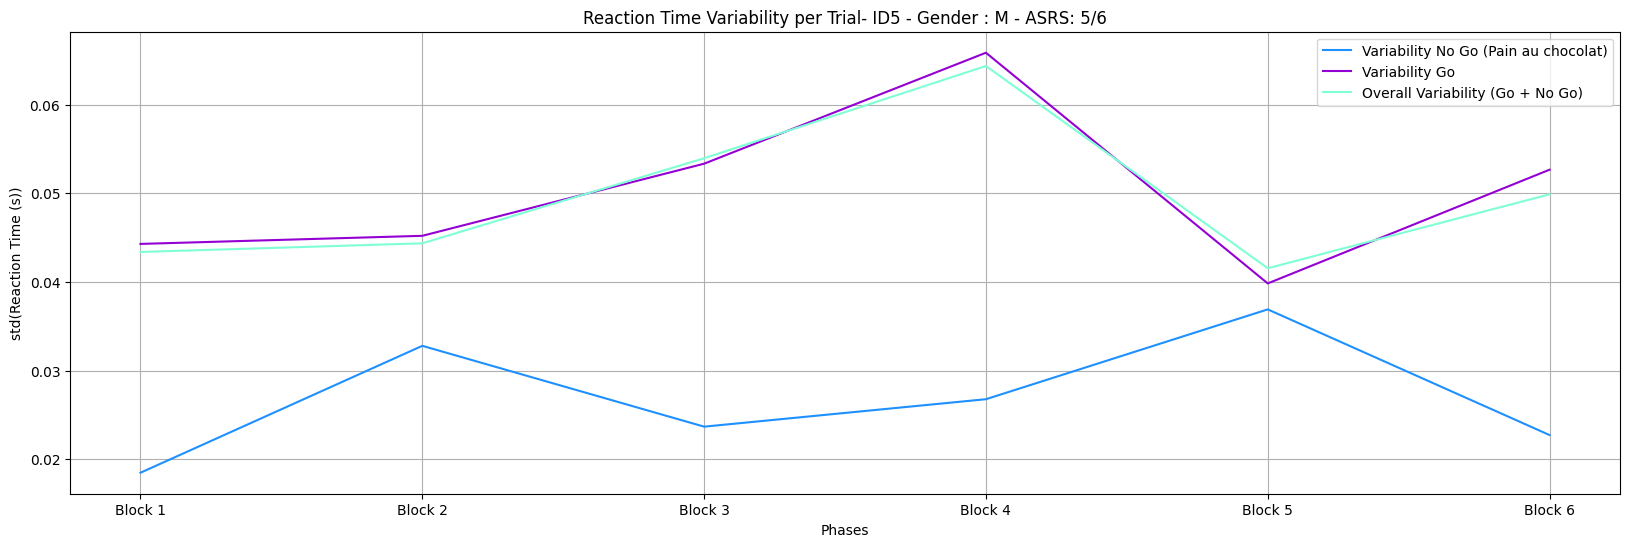

[     block_index  trial  trial_onset(s) stimulus_type resp_key     rt(s)  \
 0              1      0      258.734601            Go    space  0.731191   
 1              1      1      259.715691            Go      NaN       NaN   
 2              1      2      260.698903            Go    space  0.500298   
 3              1      3      261.683514         No_Go    space  0.582125   
 4              1      4      262.665608            Go    space  0.433281   
 ..           ...    ...             ...           ...      ...       ...   
 535            6    535      893.536112            Go    space  0.383409   
 536            6    536      894.519862            Go    space  0.285612   
 537            6    537      895.503687            Go    space  0.283464   
 538            6    538      896.487412         No_Go    space  0.318972   
 539            6    539      897.471177            Go    space  0.333473   
 
        correct  is_omission  is_comission  
 0      Correct        False 

In [ ]:
pipeline(id = 5)

In [ ]:
pipeline_statistical_test(id = 5)

{'RT_Go': np.float64(7.104901622375142e-05),
 'Omission': np.float64(0.15749134162428624),
 'Commission': np.float64(0.11531045871740034),
 'Accuracy': np.float64(0.18821397764444325)}

#**ID8**

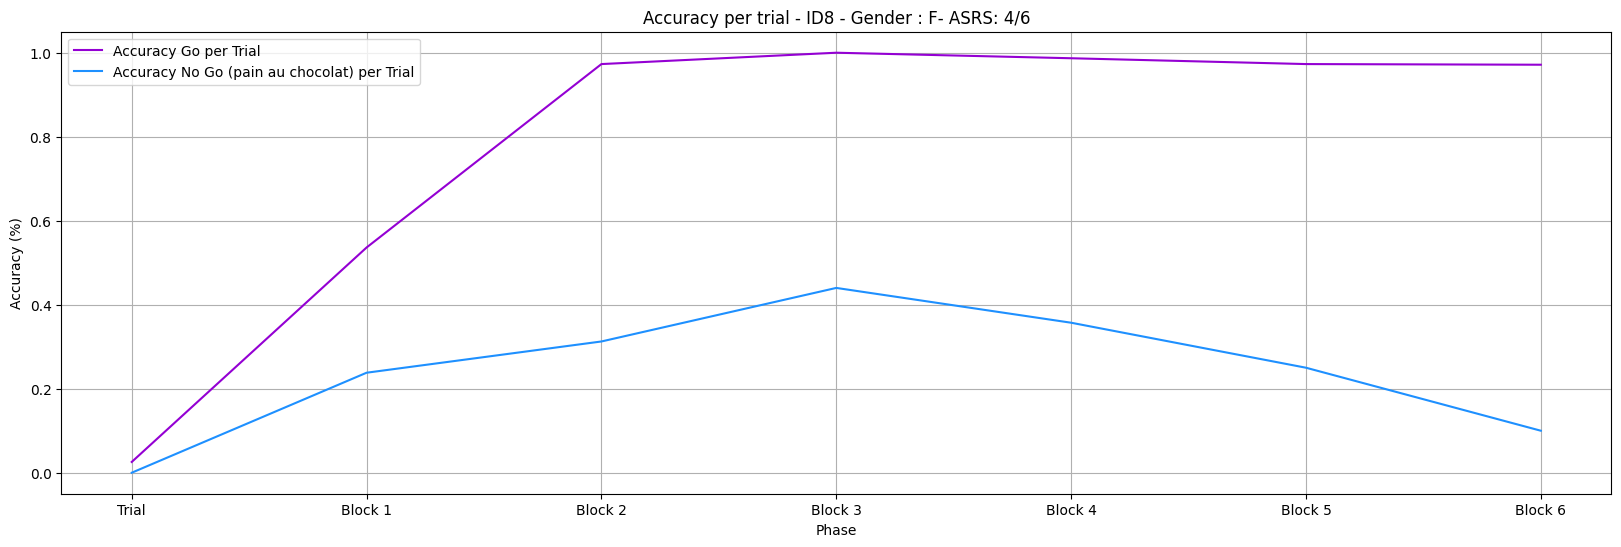

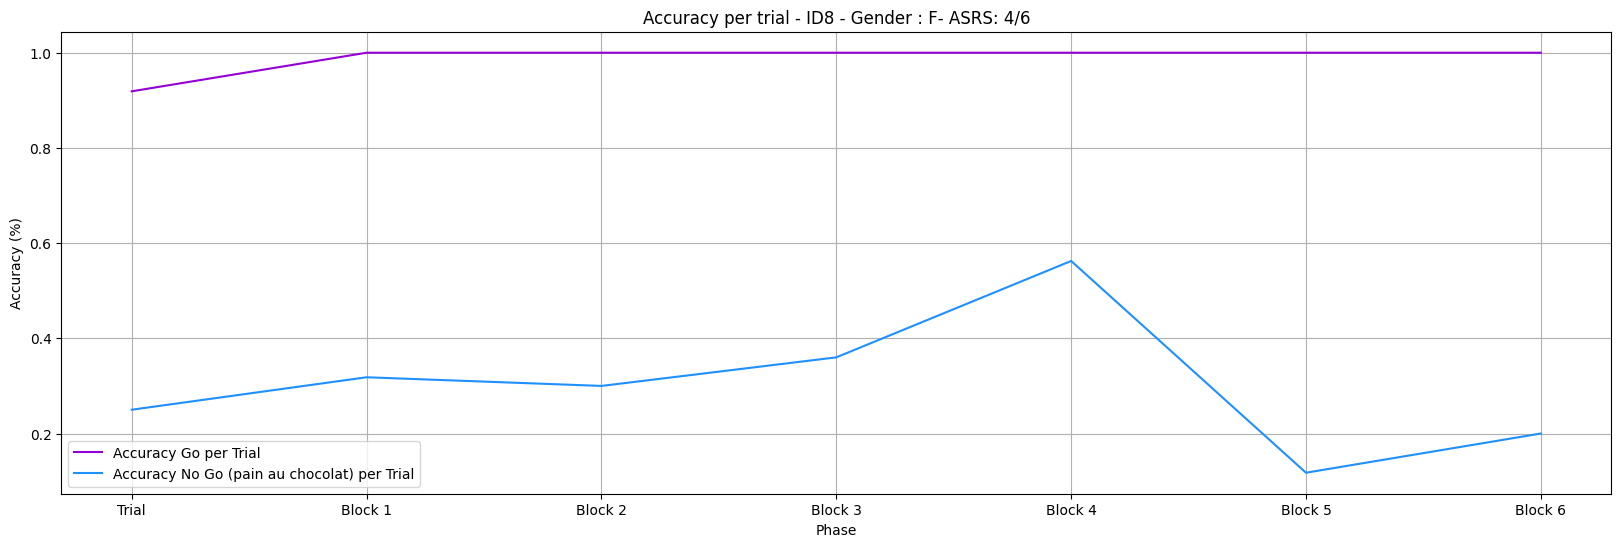

/usr/local/lib/python3.12/dist-packages/numpy/lib/_nanfunctions_impl.py:2035: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


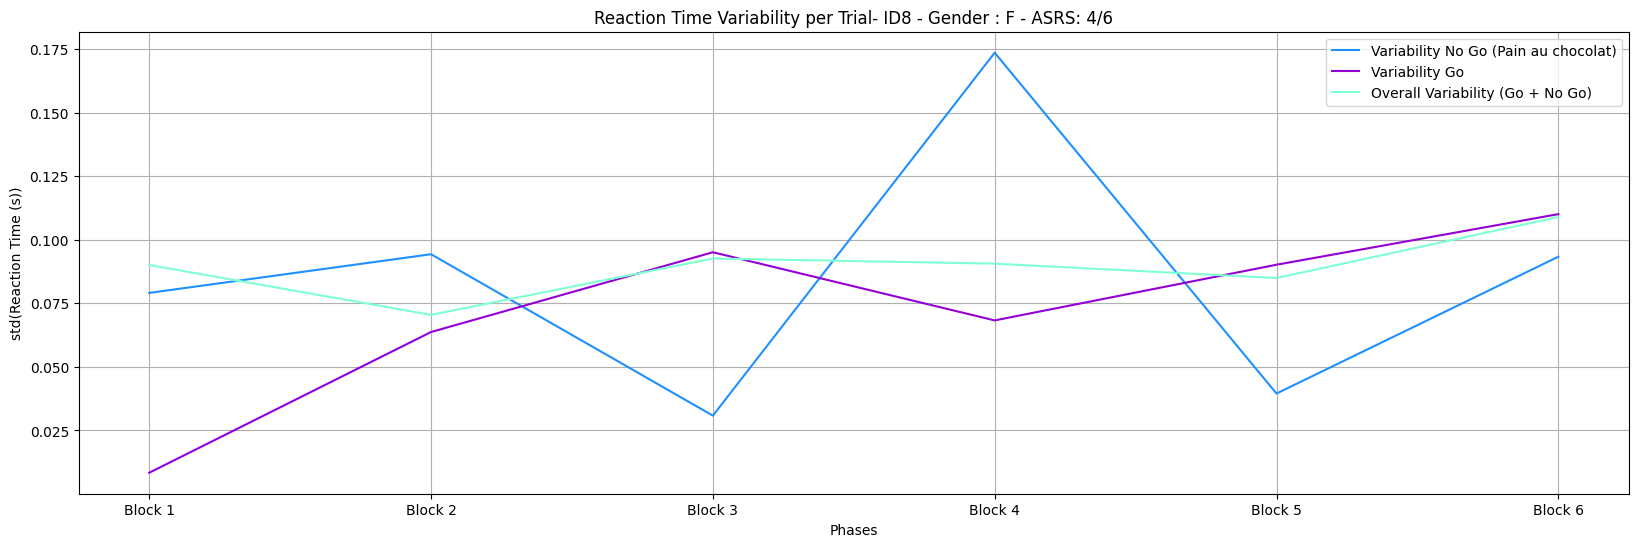

/usr/local/lib/python3.12/dist-packages/numpy/lib/_nanfunctions_impl.py:2035: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


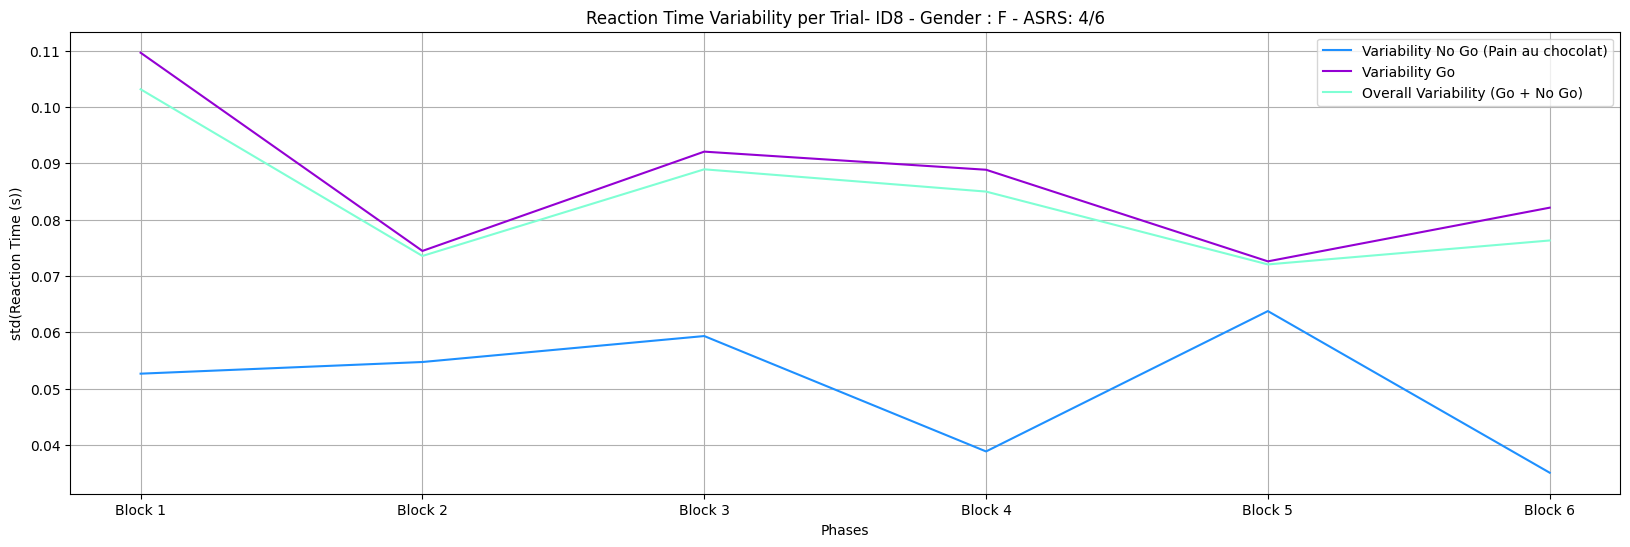

In [ ]:
pipeline(id = 8)

In [ ]:
pipeline_statistical_test(id = 8)

{'RT_Go': np.float64(0.005508490939499025),
 'Omission': np.float64(1.5030102607492702e-17),
 'Commission': np.float64(0.7925917749360817),
 'Accuracy': np.float64(1.6423032860779413e-08)}

#**ID10**

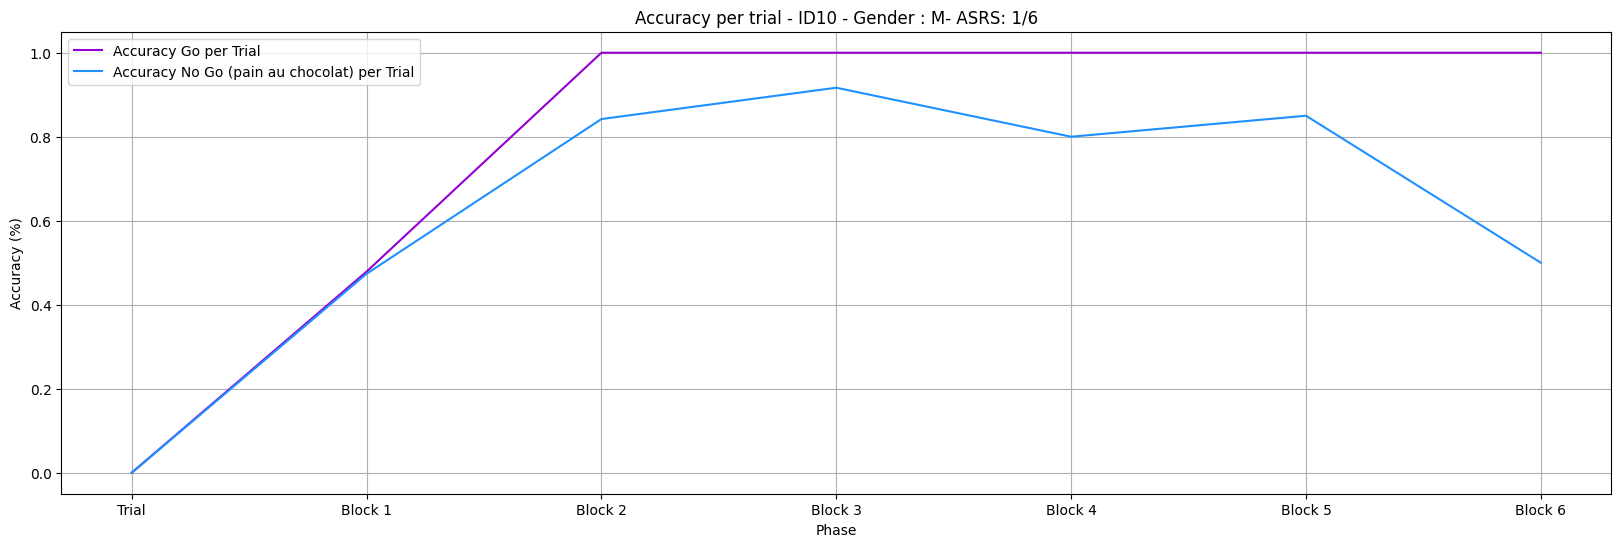

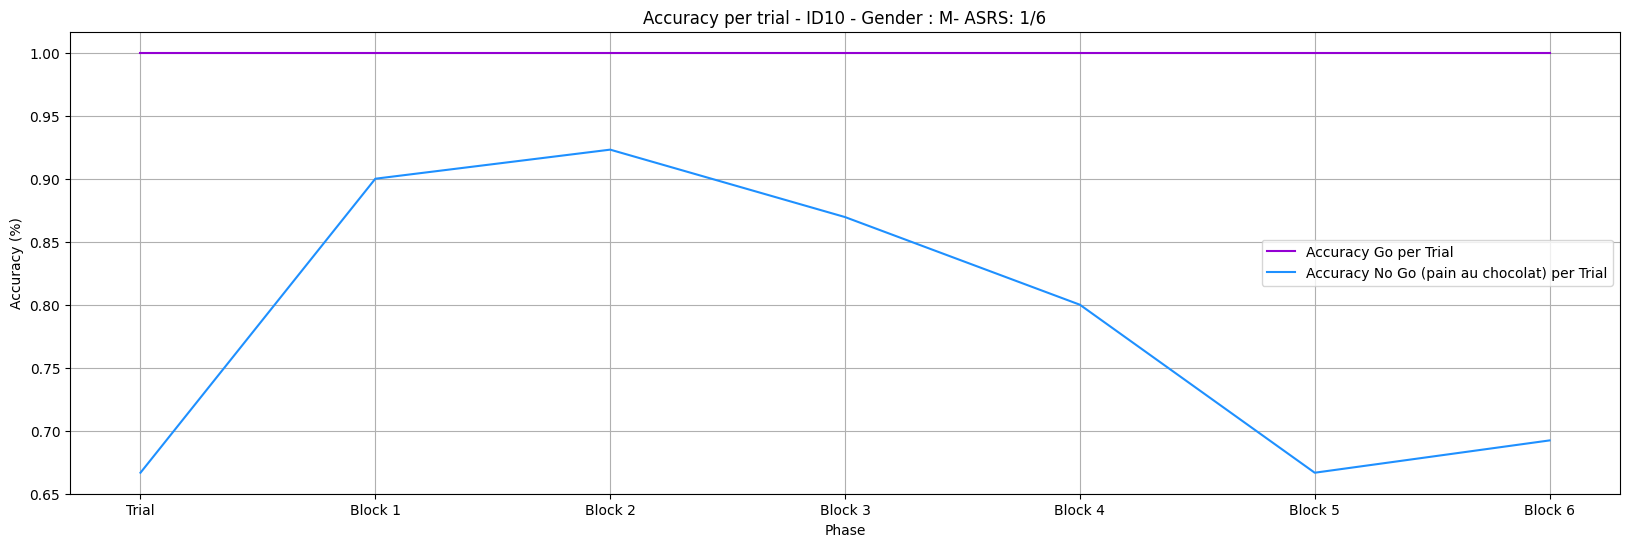

/usr/local/lib/python3.12/dist-packages/numpy/lib/_nanfunctions_impl.py:2035: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


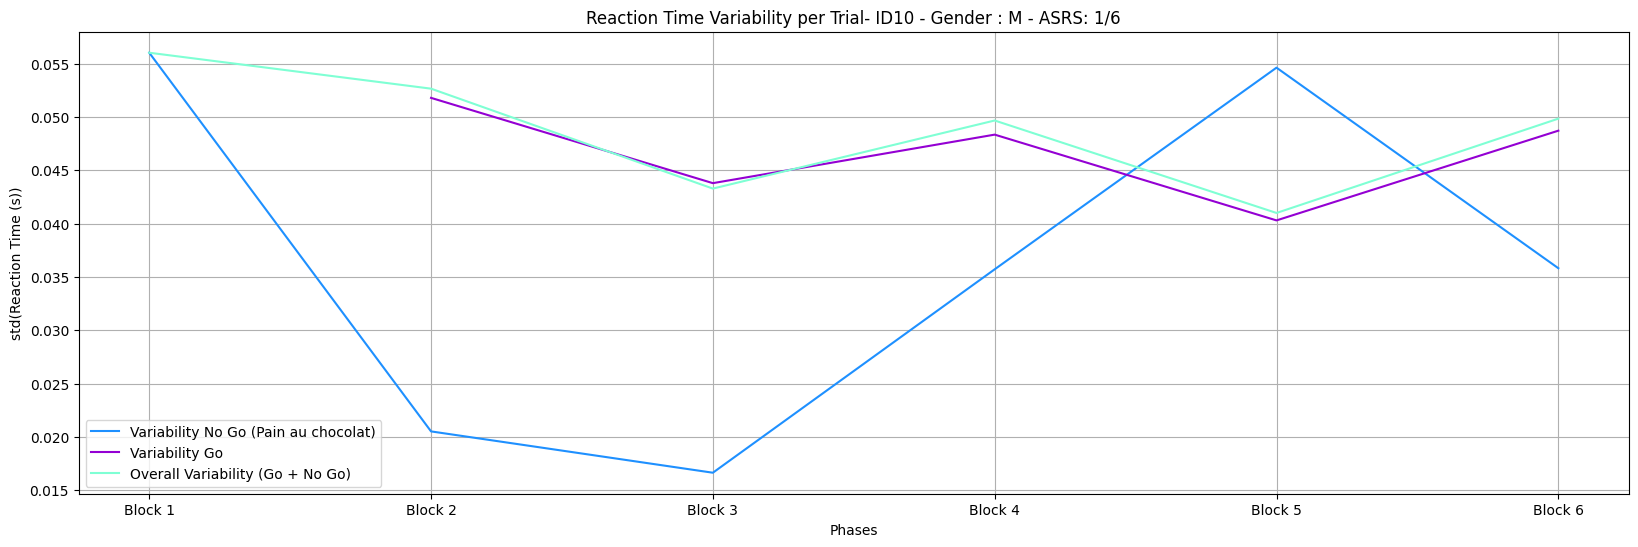

/usr/local/lib/python3.12/dist-packages/numpy/lib/_nanfunctions_impl.py:2035: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


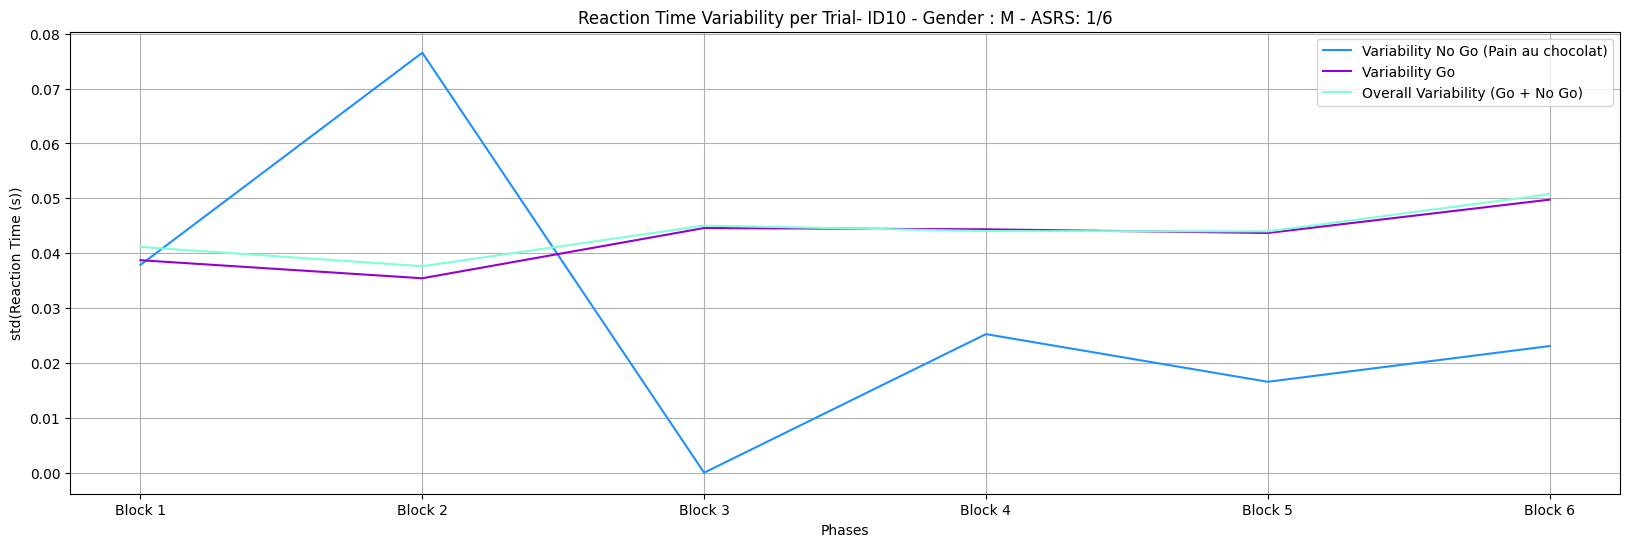

In [ ]:
pipeline(id = 10)

In [ ]:
pipeline_statistical_test(id = 10)

{'RT_Go': np.float64(0.24298261572564372),
 'Omission': np.float64(1.6521678454922696e-18),
 'Commission': np.float64(0.054837749562824153),
 'Accuracy': np.float64(5.850918747242179e-16)}

#**ID13**

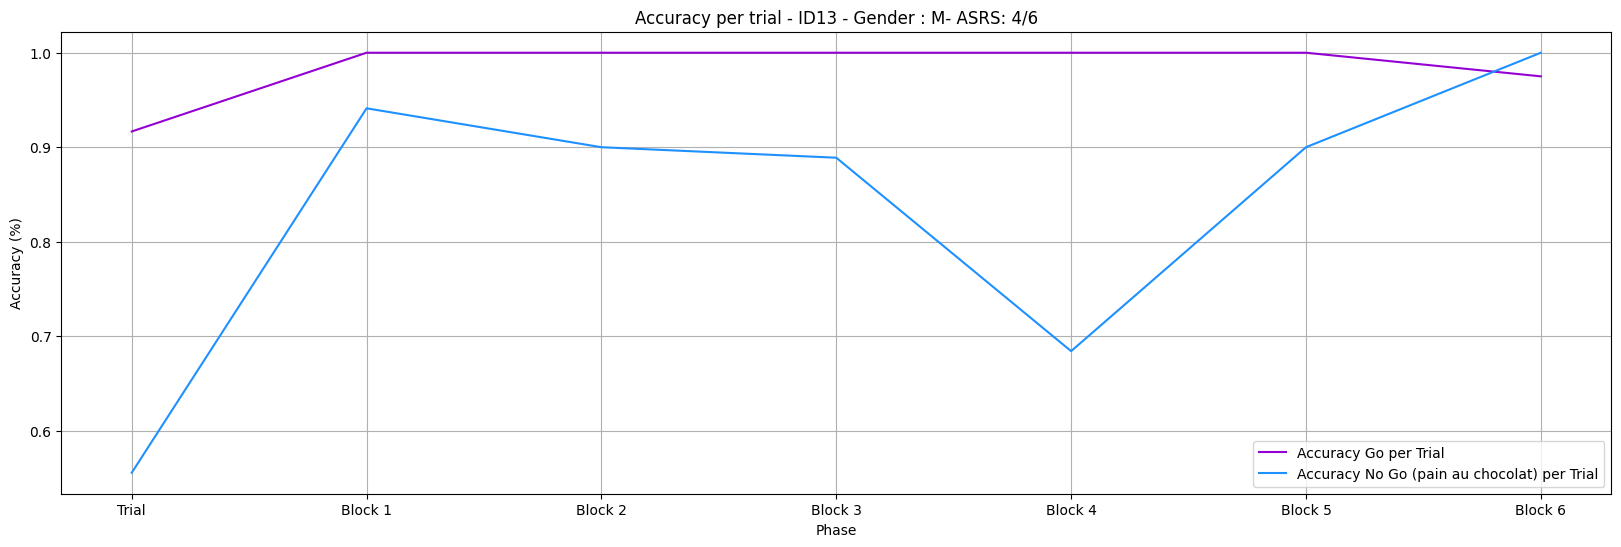

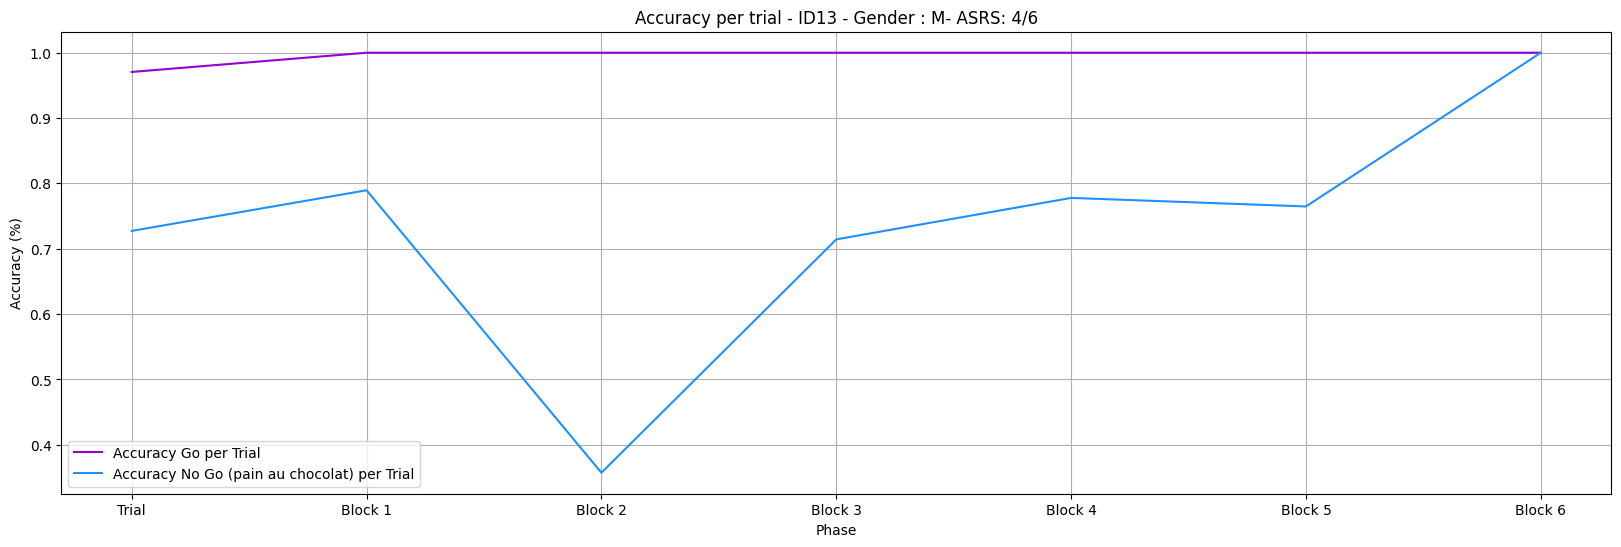

/usr/local/lib/python3.12/dist-packages/numpy/lib/_nanfunctions_impl.py:2035: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


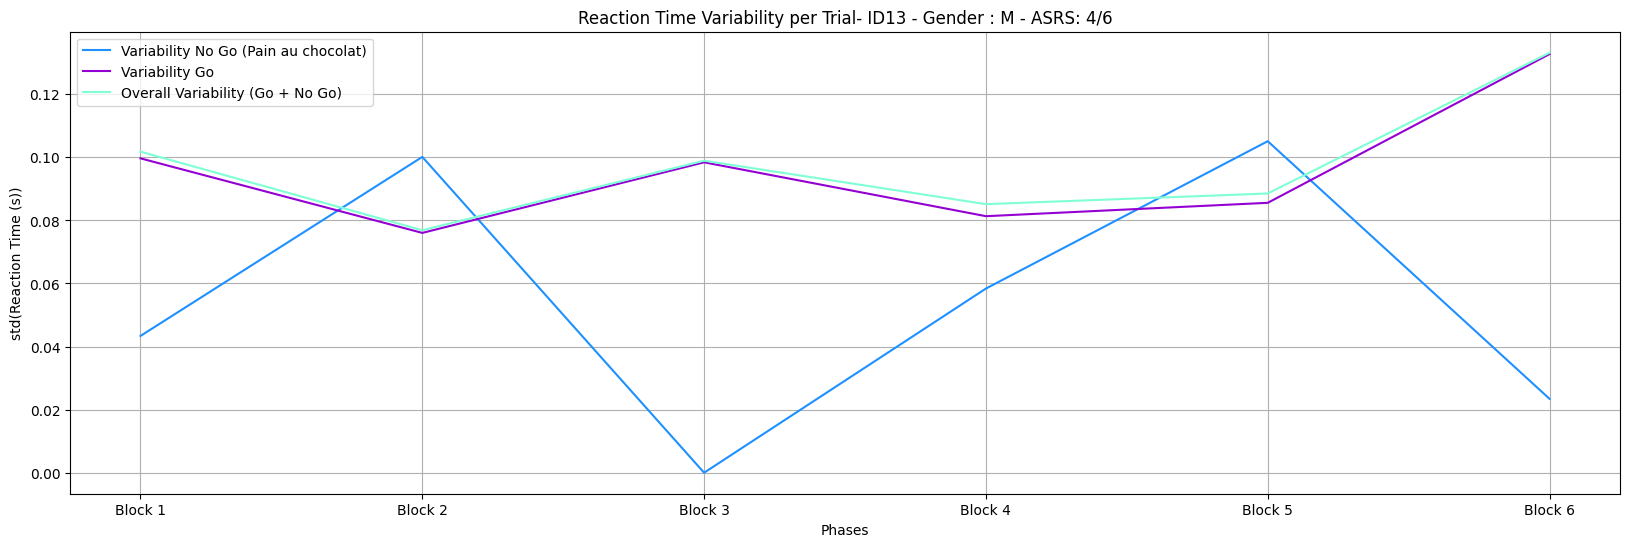

/usr/local/lib/python3.12/dist-packages/numpy/lib/_nanfunctions_impl.py:2035: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


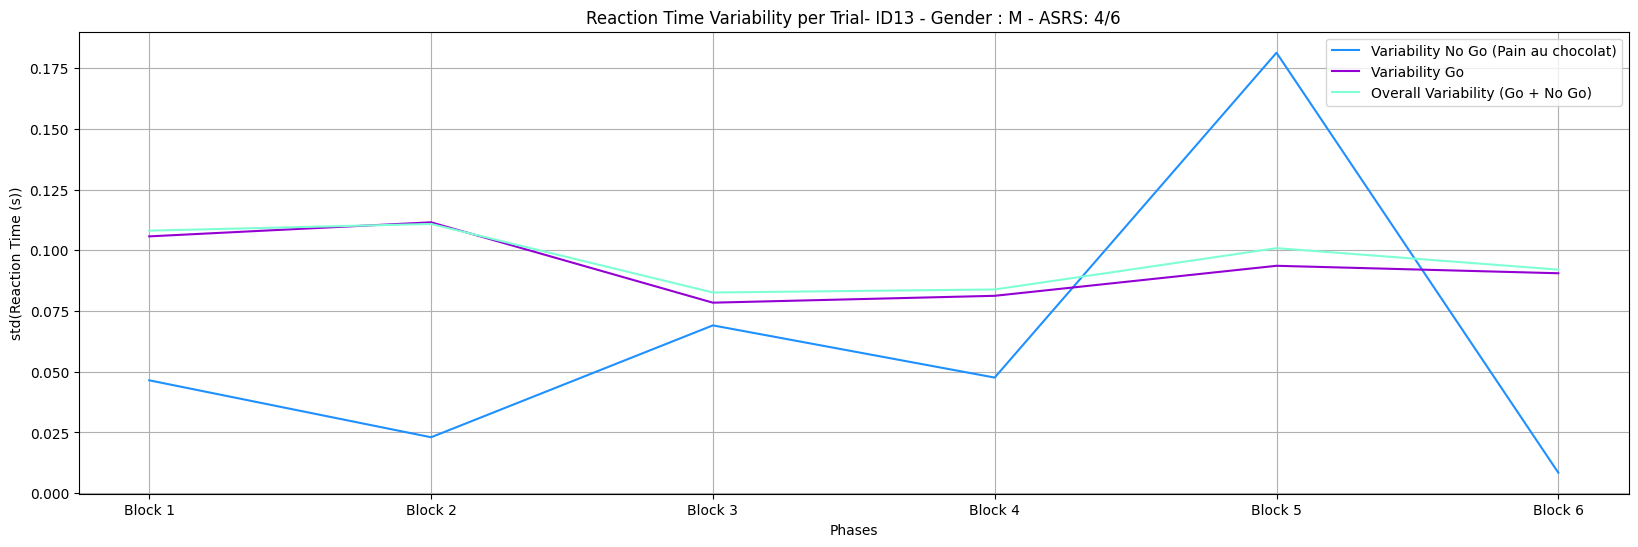

In [ ]:
pipeline(id = 13)

In [ ]:
pipeline_statistical_test(id = 13)

{'RT_Go': np.float64(1.3949686236545973e-13),
 'Omission': np.float64(0.1791732881009256),
 'Commission': np.float64(0.052656252386559216),
 'Accuracy': np.float64(0.1554709012918193)}

#**STATISTICAL TECHNIQUES**

In [ ]:
def df_results_statistical(df):

    df_sign = df.copy()

    cols = ["RT_Go", "Omission", "Commission", "Accuracy"]

    for col in cols:
        df_sign[col] = df_sign[col].apply(lambda x: x if x < 0.05 else np.nan)

    #df_sign = df_sign.fillna("")

    return df_sign

In [ ]:
all_results = []

for participant in list_participants:
    id = participant[2:]

    results = pipeline_statistical_test(id=id)

    row = {
        "ID": id,

        "RT_Go": results["RT_Go"],
        "RT_Go_improved": results["RT_Go_improved"],

        "Omission": results["Omission"],
        "Omission_improved": results["Omission_improved"],

        "Commission": results["Commission"],
        "Commission_improved": results["Commission_improved"],

        "Accuracy": results["Accuracy"],
        "Accuracy_improved": results["Accuracy_improved"]
    }

    all_results.append(row)

df_results = pd.DataFrame(all_results)
df_results

,ID,RT_Go,RT_Go_improved,Omission,Omission_improved,Commission,Commission_improved,Accuracy,Accuracy_improved
0,2,9.199409e-01,False,3.182075e-01,True,0.113286,True,9.466776e-02,True
1,6,8.146891e-11,True,8.316890e-02,True,0.403043,True,1.310255e-01,True
2,10,2.429826e-01,False,1.652168e-18,True,0.054838,True,5.850919e-16,True
3,13,1.394969e-13,True,1.791733e-01,True,0.052656,False,1.554709e-01,False
4,8,5.508491e-03,True,1.503010e-17,True,0.792592,True,1.642303e-08,True
5,5,7.104902e-05,True,1.574913e-01,True,0.115310,False,1.882140e-01,False


In [ ]:
df_results_statistical(df_results)
#ID8 I CAN AUGMENT THE DIFFICULTY, ID10 MAYBE

,ID,RT_Go,RT_Go_improved,Omission,Omission_improved,Commission,Commission_improved,Accuracy,Accuracy_improved
0,2,NaN,False,NaN,True,NaN,True,NaN,True
1,6,8.146891e-11,True,NaN,True,NaN,True,NaN,True
2,10,NaN,False,1.652168e-18,True,NaN,True,5.850919e-16,True
3,13,1.394969e-13,True,NaN,True,NaN,False,NaN,False
4,8,5.508491e-03,True,1.503010e-17,True,NaN,True,1.642303e-08,True
5,5,7.104902e-05,True,NaN,True,NaN,False,NaN,False


In [ ]:
def df_results_statistical_corrected_only(df):

    df_sign = df.copy()

    cols = ["RT_Go_corr", "Omission_corr", "Commission_corr", "Accuracy_corr"]

    for col in cols:
        df_sign[col] = df_sign[col].apply(
            lambda x: x if x < 0.05 else np.nan
        )

    df_final = df_sign[[
        "ID",
        "RT_Go_corr", "RT_Go_improved",
        "Omission_corr", "Omission_improved",
        "Commission_corr", "Commission_improved",
        "Accuracy_corr", "Accuracy_improved"
    ]]

    return df_final

In [ ]:
from statsmodels.stats.multitest import multipletests

cols = ["RT_Go", "Omission", "Commission", "Accuracy"]

#24
p_values = df_results[cols].values.flatten()
_, p_corrected, _, _ = multipletests(p_values, method='fdr_bh')
p_corrected_matrix = np.array(p_corrected).reshape(df_results[cols].shape)

for i, col in enumerate(cols):
    df_results[col + "_corr"] = p_corrected_matrix[:, i]

df_sign = df_results_statistical_corrected_only(df_results)
df_sign

,ID,RT_Go_corr,RT_Go_improved,Omission_corr,Omission_improved,Commission_corr,Commission_improved,Accuracy_corr,Accuracy_improved
0,2,NaN,False,NaN,True,NaN,True,NaN,True
1,6,3.910508e-10,True,NaN,True,NaN,True,NaN,True
2,10,NaN,False,3.965203e-17,True,NaN,True,4.680735e-15,True
3,13,8.369812e-13,True,NaN,True,NaN,False,NaN,False
4,8,1.652547e-02,True,1.803612e-16,True,NaN,True,6.569213e-08,True
5,5,2.435966e-04,True,NaN,True,NaN,False,NaN,False


In [ ]:
#@title PYSCHOPY ANALYSIS
def plot_pyschopy_marks(xdf_file):
    streams, header = pyxdf.load_xdf(xdf_file)
    flag = False

    for stream in streams:
        if (stream["info"]["name"] == ["Psychopy_markers"]) and (not flag):
            flag = True

            markers = np.array(stream["time_series"]).flatten()
            time_stamps = stream["time_stamps"]

            t0 = time_stamps[0]
            time_stamps = time_stamps - t0

            plt.figure(figsize=(20, 6))
            idx = np.where(markers == 1)[0]
            for i, t in enumerate(time_stamps[idx]):
                plt.axvline(t, linestyle="--", color="red", label="No Go" if i == 0 else "")
            idx = np.where(markers == 2)[0]
            for i, t in enumerate(time_stamps[idx]):
                plt.axvline(t, color="green", label="Go" if i == 0 else "")
            idx = np.where(markers == 3)[0]
            for i, t in enumerate(time_stamps[idx]):
                plt.axvline(t, linestyle="--", color="blue", label="No Answer" if i == 0 else "")

            plt.xlabel("Time (s)")
            plt.title("Markers (relative time)")
            plt.grid(True)
            plt.legend()
            plt.show()

(823499, 8)


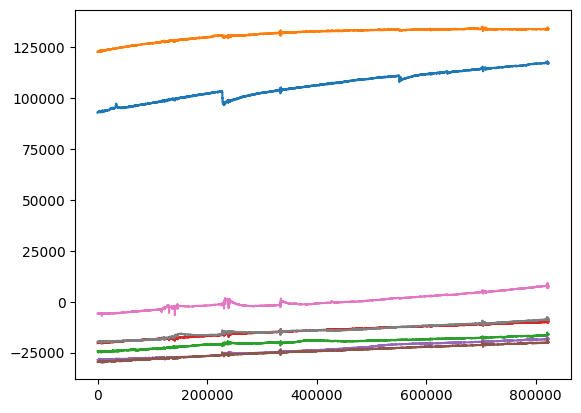

In [ ]:
streams, header = read_xdf(xdf = list_xdf[0])
for stream in streams:
  if stream["info"]["name"] == ["OpenBCI_EEG"]:
    print(stream["time_series"].shape)
    plt.plot(stream["time_series"])
    plt.show()

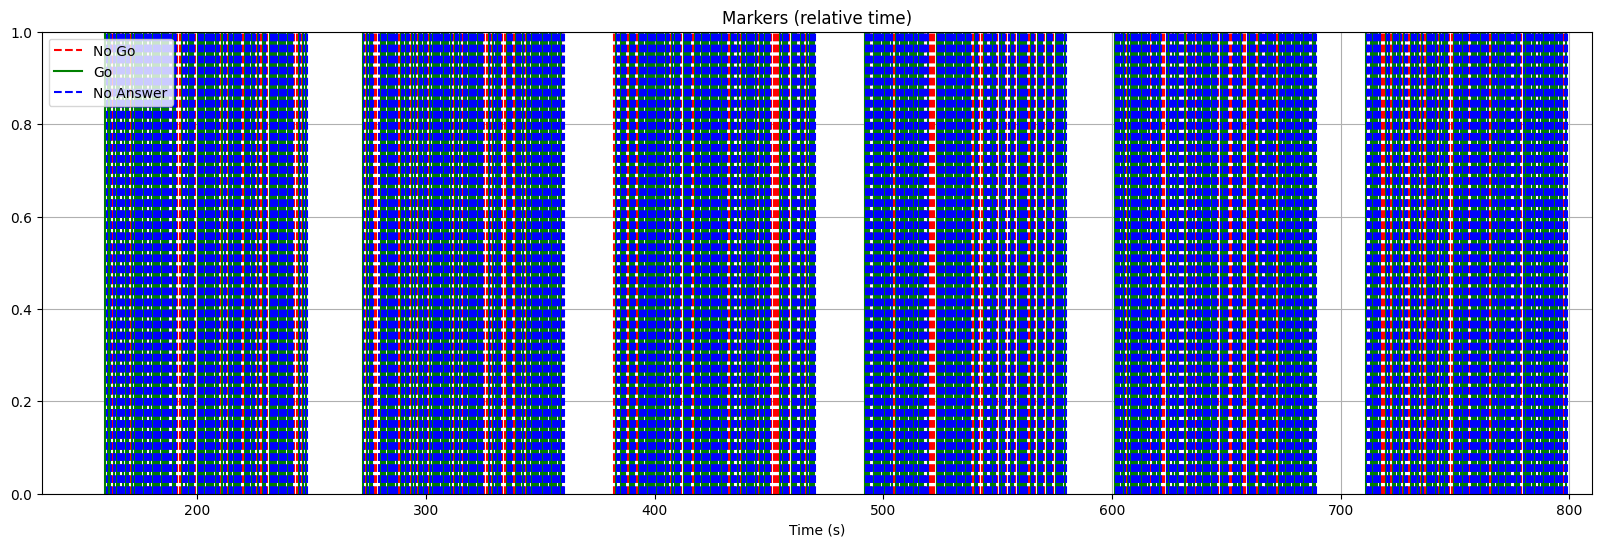

In [ ]:
streams, header = read_xdf(xdf = list_xdf[0])
plot_pyschopy_marks(xdf_file = list_xdf[0])